In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))


# Chapter 7 — Support Vector Machines (SVM)
## Lesson 8: Multi-Class SVM Strategies (OvR, OvO) and Practical Tradeoffs



In real projects, the “SVM vs non‑SVM” decision is often less important than **how you do multi-class**.

Many SVM formulations are inherently binary: they separate two sets with a maximum-margin hyperplane. But most tabular tasks are multi-class: $K \ge 3$. A practical ML engineer must understand the multi-class strategies **and their computational + statistical tradeoffs**.

This lesson focuses on:

- **OvR / One-vs-Rest** (train $K$ binary classifiers)
- **OvO / One-vs-One** (train $K(K-1)/2$ binary classifiers)
- How prediction is assembled (argmax scores vs voting, pairwise coupling)
- Why scaling, class imbalance, and score calibration matter
- What scikit-learn actually does (and how to override it)
- Empirical comparisons on multiple datasets from your repository

Throughout, we’ll implement several pipelines using `scikit-learn`, and we’ll measure not just accuracy, but also training time, macro-F1, and confusion matrices.



### Learning objectives

By the end of this notebook you should be able to:

1. Write the **binary soft-margin SVM** objective and interpret $C$ and the margin.
2. Define **OvR** and derive its prediction rule: $\hat{y}(x)=\arg\max_k f_k(x)$.
3. Define **OvO** and derive its prediction rule (majority vote and score-based coupling).
4. Compare computational costs: training/inference complexity as functions of $n$ (samples), $d$ (features), and $K$ (classes).
5. Implement OvR and OvO in scikit-learn, including pipelines with preprocessing (scaling + one-hot).
6. Diagnose when OvR may be unstable (imbalance, score scaling, overlapping classes) and when OvO may be expensive (large $K$).
7. Choose a strategy for real datasets, with principled evaluation.



## 1) Binary SVM recap (why everything starts as two-class)

Let $\{(x_i,y_i)\}_{i=1}^n$ be training data with $x_i \in \mathbb{R}^d$ and labels $y_i \in \{-1,+1\}$.
A linear classifier is $f(x)=w^\top x + b$ and predicts $\hat{y}=\mathrm{sign}(f(x))$.

### 1.1 Hard-margin SVM (separable case)

Maximize the geometric margin $2/\|w\|$ subject to correct classification:

$$
\min_{w,b} \;\frac{1}{2}\|w\|^2
\quad \text{s.t.}\quad y_i(w^\top x_i+b) \ge 1,\;\; i=1,\dots,n.
$$

### 1.2 Soft-margin SVM (non-separable case)

Introduce slack variables $\xi_i \ge 0$ and a penalty $C>0$:

$$
\min_{w,b,\xi}\;\frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i
\quad \text{s.t.}\quad y_i(w^\top x_i+b) \ge 1-\xi_i,\;\;\xi_i\ge 0.
$$

Interpretation:

- The term $\frac{1}{2}\|w\|^2$ encourages a **large margin** (small $\|w\|$).
- The term $C\sum\xi_i$ penalizes **margin violations** and misclassifications.
- Larger $C$ tries to fit the data harder (lower bias, potentially higher variance).
- Smaller $C$ allows more violations (higher bias, potentially lower variance).

### 1.3 Kernel SVM (nonlinear decision boundaries)

Replace $x$ by a feature map $\phi(x)$ and use $f(x)=w^\top \phi(x)+b$.
In dual form, $f$ depends only on kernel evaluations $K(x_i,x)=\phi(x_i)^\top \phi(x)$:

$$
f(x)=\sum_{i=1}^n \alpha_i y_i K(x_i,x) + b.
$$

This is the “kernel trick”: we never need to explicitly construct $\phi$.



## 2) The multi-class problem: $K \ge 3$

Now suppose $y_i \in \{1,2,\dots,K\}$.
A general score-based multi-class classifier computes $K$ real-valued scores:

$$
f_1(x), f_2(x), \dots, f_K(x),
$$

and predicts

$$
\hat{y}(x)=\arg\max_{k\in\{1,\dots,K\}} f_k(x).
$$

For logistic regression, these scores can be aligned with probabilities via the softmax.
For SVMs, the natural object is a **margin score** (distance to a separating hyperplane).
But **how do we get $K$ scores when SVM is binary?**

There are two classic decomposition strategies:

1. **One-vs-Rest (OvR)**: train $K$ binary SVMs, one per class vs the rest.
2. **One-vs-One (OvO)**: train $\binom{K}{2}$ binary SVMs, one per pair.

There also exist *direct* multi-class SVM formulations (e.g., Crammer–Singer), which we’ll briefly discuss later.



## 3) One-vs-Rest (OvR): definition, prediction, and pitfalls

### 3.1 Training construction

For each class $k \in \{1,\dots,K\}$ define binary labels:

$$
y_i^{(k)} =
\begin{cases}
+1 & \text{if } y_i = k,\\
-1 & \text{otherwise.}
\end{cases}
$$

Then train a binary SVM for each $k$:

$$
f_k(x)=w_k^\top \phi(x)+b_k.
$$

### 3.2 Prediction rule

Given the $K$ decision functions, predict:

$$
\hat{y}(x)=\arg\max_k f_k(x).
$$

This is attractive because it is conceptually simple and uses only $K$ classifiers.

### 3.3 Practical pitfalls (very important)

OvR often works well with **linear SVMs** (especially high-dimensional sparse data),
but it can be tricky when:

1. **Class imbalance**: the “rest” class is huge compared to the positive class, so the hyperplane may be biased.
   Use `class_weight="balanced"` or custom weights.
2. **Score scaling mismatch**: $f_k(x)$ values across $k$ are not guaranteed to be comparable.
   Different $w_k$ norms, different support vector structures, and different slack patterns can scale the margin.
   If the scores are not comparable, $\arg\max_k f_k(x)$ can be unstable.
3. **Overlapping classes**: multiple classifiers can output positive margins simultaneously.
   Or all can output negative margins (no class “wins” strongly). You still do argmax, but confidence becomes messy.
4. **Calibration**: if you need probabilities, you must calibrate (Platt scaling, isotonic).
   Calibration is typically done per binary classifier and may not yield globally consistent multi-class probabilities.

A useful mental model:

- OvR yields a vector of margins $f(x) \in \mathbb{R}^K$.
- If there exists a monotone map $g$ such that $g(f_k(x))$ approximates $P(Y=k\mid x)$,
  then argmax is sensible.
- Without calibration, margins are *not* guaranteed to be probability-ordered.



## 4) One-vs-One (OvO): definition, voting, and pairwise coupling

### 4.1 Training construction

For every pair of classes $(a,b)$ with $1 \le a < b \le K$, train a binary SVM using only samples from these two classes.
This yields $\binom{K}{2}$ classifiers:

$$
f_{ab}(x) = w_{ab}^\top \phi(x) + b_{ab}.
$$

### 4.2 Majority vote prediction

Each classifier predicts either $a$ or $b$.
Aggregate votes:

$$
\hat{y}(x)=\arg\max_{k} \sum_{a<b} \mathbf{1}\{\text{classifier } (a,b)\text{ votes for }k\}.
$$

This is a “tournament”: every pair plays a match; the class with most wins is predicted.

### 4.3 Why OvO can be strong with kernel SVMs

Kernel SVM training is often superlinear in $n$ (depending on solver).
In OvO, each model sees only a subset of the data (two classes), so each problem is smaller.
Even though you train many models, each one can be cheaper.

### 4.4 Pairwise coupling (score-based aggregation)

Instead of votes, you can use pairwise decision values or estimated probabilities.
If you can estimate pairwise probabilities

$$
p_{ab}(x) \approx P(Y=a \mid Y \in \{a,b\}, x),
$$

you can “couple” them to obtain multi-class probabilities $P(Y=k\mid x)$ by solving a constrained optimization problem.
This is used in some libraries to produce consistent probability vectors.

### 4.5 Pitfalls

- OvO requires $\binom{K}{2}$ models. If $K$ is large (e.g., hundreds), this is expensive in memory and inference time.
- Voting can be sensitive to ties. Score-based coupling can reduce ties but adds complexity.



## 5) Computational tradeoffs (training + inference)

Let:

- $n$ = total samples
- $d$ = number of features after preprocessing
- $K$ = number of classes

### 5.1 Number of models

- OvR: $K$
- OvO: $\binom{K}{2} = K(K-1)/2$

### 5.2 Training set sizes per model

- OvR: each model uses all $n$ samples (with relabeled targets).
- OvO: each model uses only samples from two classes: roughly $n_a + n_b$.

If classes are balanced, each pair sees about $2n/K$ samples on average.

### 5.3 Rough training cost intuition

For **linear SVMs**, training is often near-linear in $n$ and $d$ (solver-dependent). OvR is typically attractive.

For **kernel SVMs**, training can be closer to $O(n^2)$ memory/time in worst-case scenarios.
Then OvO can be surprisingly competitive because each subproblem can be much smaller.

### 5.4 Inference cost

Assume evaluating one decision function costs $O(d)$ for linear and at least $O(s)$ kernel evaluations (where $s$ is #support vectors) for kernel SVM.

- OvR inference: compute $K$ scores, pick argmax.
- OvO inference: compute $\binom{K}{2}$ pairwise decisions (or a subset if using DAG-style schemes).

So OvO can be slower at inference when $K$ is large.

### 5.5 Summary table

| Strategy | #Models | Train data per model | Typical use-case | Common pitfalls |
|---|---:|---:|---|---|
| OvR | $K$ | $\approx n$ | Linear SVM, sparse high-dim | imbalance, score comparability |
| OvO | $K(K-1)/2$ | $\approx 2n/K$ (balanced) | Kernel SVM, moderate $K$ | memory/inference for large $K$ |



## 6) What scikit-learn does by default (important)

In `scikit-learn`:

- `sklearn.svm.SVC` (kernel SVM) uses **OvO** internally for multi-class classification.
- `sklearn.svm.LinearSVC` uses **OvR** by default (`multi_class="ovr"`), and also offers `multi_class="crammer_singer"`.

You can also explicitly wrap estimators using:

- `sklearn.multiclass.OneVsRestClassifier`
- `sklearn.multiclass.OneVsOneClassifier`

This is useful when you want:

- Control of the strategy independent of estimator defaults
- Separate calibration steps
- Parallelization via `n_jobs`
- Consistent evaluation across models

We’ll compare both approaches in practice.


In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

from sklearn.svm import SVC, LinearSVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def read_csv_safely(path: str) -> pd.DataFrame:
    """Read CSV; if not found, raise a clear error with the expected relative path."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File not found: {path}\n"
            "Make sure your repo has the Datasets/ folder and you run this notebook from Tutorials/*/Chapter7/.\n"
            "Expected relative paths look like '../../../Datasets/...'."
        )
    return pd.read_csv(path)

def evaluate_model(model, X_train, X_test, y_train, y_test, title: str):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t1 = time.perf_counter()
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro')
    print(f"{title}")
    print(f"  Train time: {t1-t0:.3f} s")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Macro-F1:   {f1m:.4f}")
    print()
    print(classification_report(y_test, y_pred))
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
    disp.ax_.set_title(f"Confusion Matrix — {title}")
    plt.show()
    return {'title': title, 'train_time_s': t1-t0, 'accuracy': acc, 'macro_f1': f1m}

def pca_scatter_2d(X, y, title: str):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X2 = pca.fit_transform(X)
    plt.figure()
    for cls in np.unique(y):
        m = (y == cls)
        plt.scatter(X2[m, 0], X2[m, 1], label=str(cls), alpha=0.7)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()



## 7) Experiment 1 — Iris (clean multi-class baseline)

We start with `iris.csv`, which is a classic 3-class dataset with 4 numeric features.
This is a good sandbox to see strategy differences without heavy preprocessing.

Dataset path (relative to `Tutorials/*/Chapter7/`):

- `"../../../Datasets/Classification/iris.csv"`

We will:

1. Load data
2. Train a kernel SVM (`SVC`) and compare:
   - default multi-class behavior (OvO internal)
   - explicit OvR wrapper
3. Compare training time, accuracy, macro-F1, and confusion matrix
4. Visualize the data in 2D via PCA (for intuition)


In [3]:
iris_path = "../../../Datasets/Classification/iris.csv"
df_iris = read_csv_safely(iris_path)
df_iris.head()


,sepal_length,sepal_width,petal_length,petal_width,classification
0,5.4,3.7,1.5,0.2,Iris-setosa
1,4.8,3.4,1.6,0.2,Iris-setosa
2,4.8,3.0,1.4,0.1,Iris-setosa
3,4.3,3.0,1.1,0.1,Iris-setosa
4,5.8,4.0,1.2,0.2,Iris-setosa


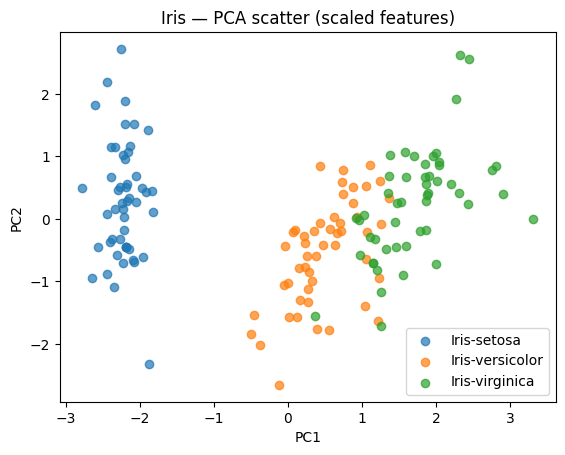

In [4]:
target_col = "classification"
X = df_iris.drop(columns=[target_col])
y = df_iris[target_col].astype(str).values  # keep labels as strings for clarity

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

numeric_features = list(X.columns)

preprocess_num = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)

# Kernel SVM baseline (default multi-class strategy is OvO in SVC)
svc_default = Pipeline([
    ("prep", preprocess_num),
    ("svc", SVC(kernel="rbf", C=3.0, gamma="scale"))
])

# Explicit OvR wrapper around the same base estimator
svc_ovr = Pipeline([
    ("prep", preprocess_num),
    ("clf", OneVsRestClassifier(SVC(kernel="rbf", C=3.0, gamma="scale")))
])

# Explicit OvO wrapper (mostly redundant for SVC, but shown for symmetry)
svc_ovo = Pipeline([
    ("prep", preprocess_num),
    ("clf", OneVsOneClassifier(SVC(kernel="rbf", C=3.0, gamma="scale")))
])

# PCA scatter plot (after scaling)
X_scaled = preprocess_num.fit_transform(X)
pca_scatter_2d(X_scaled, y, title="Iris — PCA scatter (scaled features)")


Iris — SVC default (OvO internal)
  Train time: 0.012 s
  Accuracy:   0.9474
  Macro-F1:   0.9487

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.95        38
      macro avg       0.95      0.95      0.95        38
   weighted avg       0.95      0.95      0.95        38



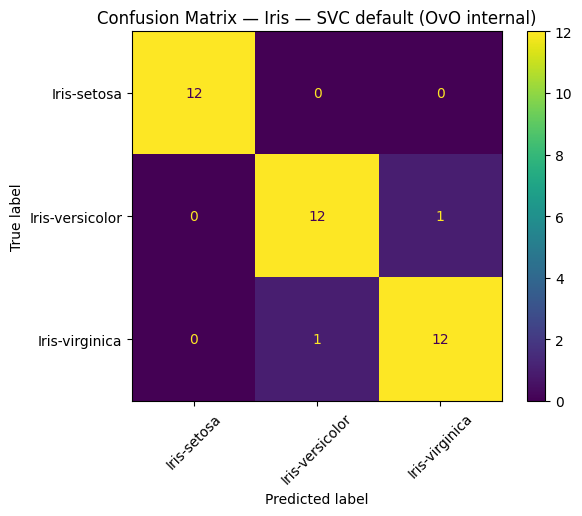

Iris — SVC wrapped with OneVsRest (OvR)
  Train time: 0.013 s
  Accuracy:   0.9474
  Macro-F1:   0.9487

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.95        38
      macro avg       0.95      0.95      0.95        38
   weighted avg       0.95      0.95      0.95        38



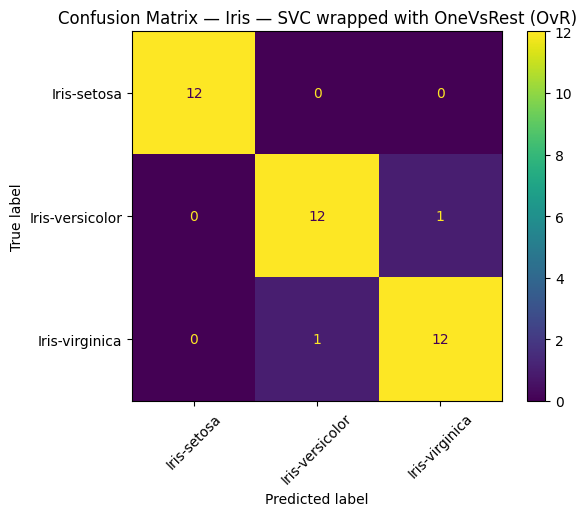

Iris — SVC wrapped with OneVsOne (OvO)
  Train time: 0.011 s
  Accuracy:   0.9211
  Macro-F1:   0.9230

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.86      0.92      0.89        13
 Iris-virginica       0.92      0.85      0.88        13

       accuracy                           0.92        38
      macro avg       0.92      0.92      0.92        38
   weighted avg       0.92      0.92      0.92        38



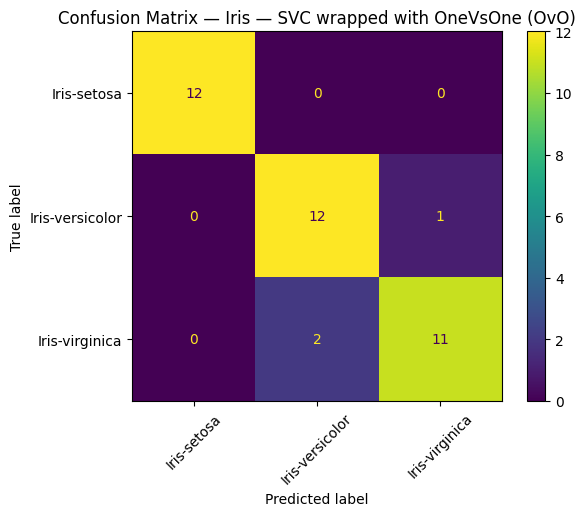

,title,train_time_s,accuracy,macro_f1
0,Iris — SVC default (OvO internal),0.011833,0.947368,0.948718
1,Iris — SVC wrapped with OneVsRest (OvR),0.013480,0.947368,0.948718
2,Iris — SVC wrapped with OneVsOne (OvO),0.010614,0.921053,0.922963


In [5]:
results = []
results.append(evaluate_model(svc_default, X_train, X_test, y_train, y_test, "Iris — SVC default (OvO internal)"))
results.append(evaluate_model(svc_ovr,     X_train, X_test, y_train, y_test, "Iris — SVC wrapped with OneVsRest (OvR)"))
results.append(evaluate_model(svc_ovo,     X_train, X_test, y_train, y_test, "Iris — SVC wrapped with OneVsOne (OvO)"))

pd.DataFrame(results).sort_values(by=["macro_f1","accuracy"], ascending=False)



### Interpretation (Iris)

On Iris, you often see small differences because the dataset is clean and separable enough.

Key takeaways:

- `SVC` uses OvO internally, so the explicit OvO wrapper often matches or is very similar.
- OvR may be slightly different because its argmax is based on $K$ independently trained margins.
- Differences become larger on noisier datasets (more overlap) or with strong imbalance.

In production, you rarely choose OvR vs OvO based only on Iris-like behavior; you consider:

- $K$ (number of classes)
- Kernel vs linear
- Data size and compute budget
- Calibration needs and downstream decisioning



## 8) Experiment 2 — Glass (harder multi-class with overlap)

Now we try `glass.csv`, which has multiple glass types as labels and features related to chemical composition.
This dataset tends to be more challenging and can expose differences between OvR and OvO.

Dataset path:

- `"../../../Datasets/Classification/glass.csv"`

We’ll run:

- Linear-ish baseline (RBF SVC still nonlinear, but we’ll examine sensitivity)
- Evaluate OvR vs OvO with the same hyperparameters
- Use `class_weight="balanced"` to reduce imbalance effects


In [6]:
glass_path = "../../../Datasets/Classification/glass.csv"
df_glass = read_csv_safely(glass_path)
df_glass.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


Glass — RBF SVC (OvR wrapper)
  Train time: 0.021 s
  Accuracy:   0.7222
  Macro-F1:   0.7200

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.68      0.72      0.70        18
building_windows_non_float_processed       0.68      0.68      0.68        19
                          containers       1.00      1.00      1.00         3
                           headlamps       1.00      0.88      0.93         8
                           tableware       0.50      0.50      0.50         2
     vehicle_windows_float_processed       0.50      0.50      0.50         4

                            accuracy                           0.72        54
                           macro avg       0.73      0.71      0.72        54
                        weighted avg       0.73      0.72      0.72        54



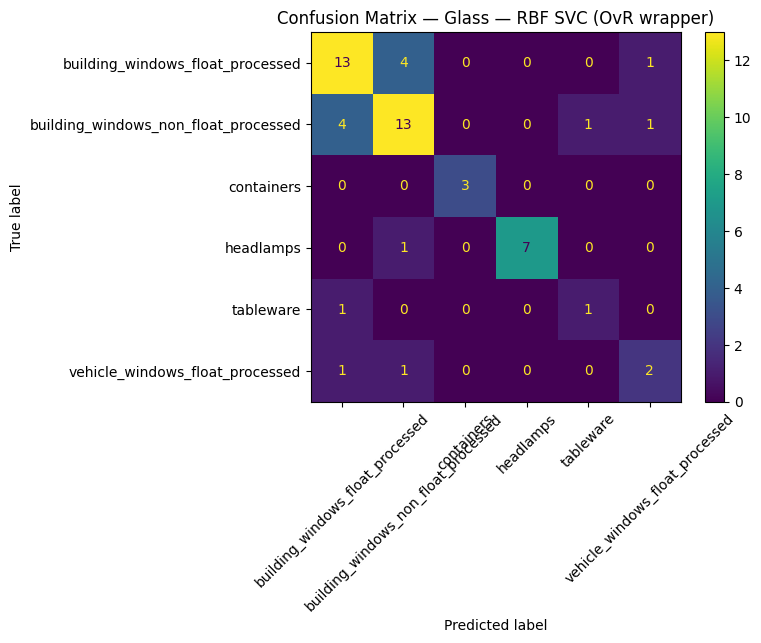

Glass — RBF SVC (OvO wrapper)
  Train time: 0.041 s
  Accuracy:   0.7407
  Macro-F1:   0.7721

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.68      0.72      0.70        18
building_windows_non_float_processed       0.75      0.63      0.69        19
                          containers       1.00      1.00      1.00         3
                           headlamps       1.00      1.00      1.00         8
                           tableware       0.67      1.00      0.80         2
     vehicle_windows_float_processed       0.40      0.50      0.44         4

                            accuracy                           0.74        54
                           macro avg       0.75      0.81      0.77        54
                        weighted avg       0.75      0.74      0.74        54



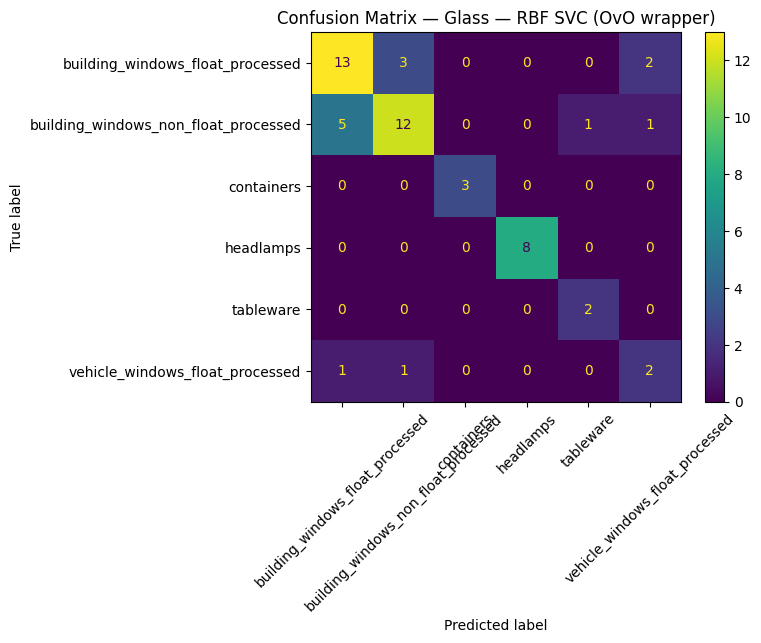

,title,train_time_s,accuracy,macro_f1
0,Glass — RBF SVC (OvR wrapper),0.020957,0.722222,0.720041
1,Glass — RBF SVC (OvO wrapper),0.041224,0.740741,0.772144


In [7]:
target_col = "Type"
Xg = df_glass.drop(columns=[target_col])
yg = df_glass[target_col].astype(str).values

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.25, random_state=RANDOM_STATE, stratify=yg
)

num_cols_g = list(Xg.columns)

prep_g = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols_g)],
    remainder="drop"
)

base_svc = SVC(kernel="rbf", C=5.0, gamma="scale", class_weight="balanced")

glass_ovr = Pipeline([("prep", prep_g), ("clf", OneVsRestClassifier(base_svc))])
glass_ovo = Pipeline([("prep", prep_g), ("clf", OneVsOneClassifier(base_svc))])

results_glass = []
results_glass.append(evaluate_model(glass_ovr, Xg_train, Xg_test, yg_train, yg_test, "Glass — RBF SVC (OvR wrapper)"))
results_glass.append(evaluate_model(glass_ovo, Xg_train, Xg_test, yg_train, yg_test, "Glass — RBF SVC (OvO wrapper)"))
pd.DataFrame(results_glass)



## 9) A deeper look: why OvR scores can be “non-comparable”

OvR uses:

$$
\hat{y}(x)=\arg\max_k f_k(x)
$$

But each $f_k$ is trained on a *different* binary problem with different positive/negative compositions.
Even if all models share the same $C$ and kernel hyperparameters, their **margin scales** can differ.

One way to see the issue:

- The optimal solution $(w_k,b_k)$ depends on the class frequency and overlap.
- The distribution of slack variables $\{\xi_i\}$ differs by $k$.
- The resulting $w_k$ norms can differ, and raw decision values $f_k(x)$ are not normalized probabilities.

A common mitigation is to calibrate each binary classifier:

- Fit $p_k(x)=\sigma(a_k f_k(x)+c_k)$ (Platt scaling) on a validation set.
- Then predict $\hat{y}=\arg\max_k p_k(x)$.

However, even calibrated per-class probabilities can be inconsistent (they might not sum to 1 unless you renormalize).
Some systems renormalize:

$$
\tilde{p}_k(x)=\frac{p_k(x)}{\sum_{j=1}^K p_j(x)}.
$$

This can help decisioning, but it’s not a theoretically perfect multi-class probability model.

OvO + pairwise coupling is another route: estimate pairwise probabilities and solve for a consistent simplex vector.



## 10) Experiment 3 — Drug200 (mixed categorical + numeric features)

`drug200.csv` is a great example of a real tabular pipeline:

- Numeric: `Age`, `Na_to_K`
- Categorical: `Sex`, `BP`, `Cholesterol`
- Target: `Drug` (multi-class)

Dataset path:

- `"../../../Datasets/Classification/drug200.csv"`

Here we will show why **linear SVM + OvR** is often the default for high-dimensional one-hot features.
We will:

1. Build a `ColumnTransformer` with `OneHotEncoder` + `StandardScaler`
2. Compare OvR vs OvO using `LinearSVC`
3. Discuss the effect of `class_weight="balanced"` and regularization strength `C`


In [8]:
drug_path = "../../../Datasets/Classification/drug200.csv"
df_drug = read_csv_safely(drug_path)
df_drug.head()


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Drug200 — LinearSVC (OvR wrapper)
  Train time: 0.056 s
  Accuracy:   0.9800
  Macro-F1:   0.9881

              precision    recall  f1-score   support

       DrugY       1.00      0.96      0.98        23
       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         4
       drugC       1.00      1.00      1.00         4
       drugX       0.93      1.00      0.96        13

    accuracy                           0.98        50
   macro avg       0.99      0.99      0.99        50
weighted avg       0.98      0.98      0.98        50



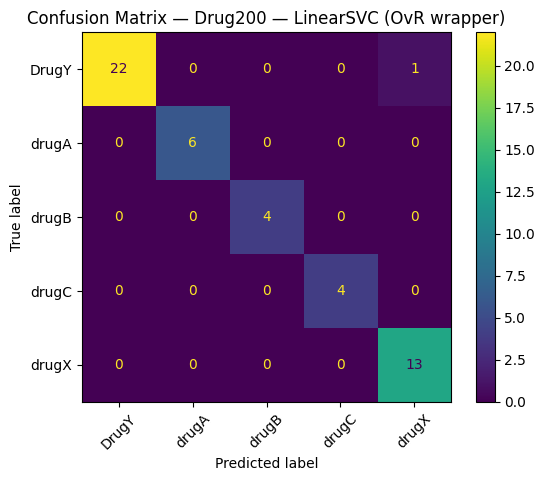

Drug200 — LinearSVC (OvO wrapper)
  Train time: 0.050 s
  Accuracy:   0.9600
  Macro-F1:   0.9613

              precision    recall  f1-score   support

       DrugY       1.00      0.91      0.95        23
       drugA       1.00      1.00      1.00         6
       drugB       0.80      1.00      0.89         4
       drugC       1.00      1.00      1.00         4
       drugX       0.93      1.00      0.96        13

    accuracy                           0.96        50
   macro avg       0.95      0.98      0.96        50
weighted avg       0.97      0.96      0.96        50



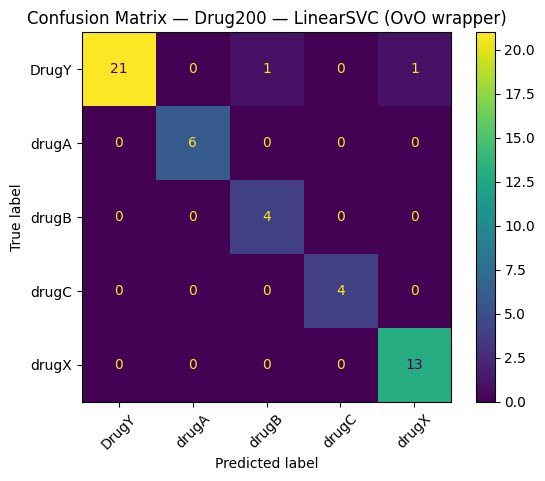

,title,train_time_s,accuracy,macro_f1
0,Drug200 — LinearSVC (OvR wrapper),0.056475,0.98,0.988148
1,Drug200 — LinearSVC (OvO wrapper),0.050476,0.96,0.961279


In [9]:
target_col = "Drug"
Xd = df_drug.drop(columns=[target_col])
yd = df_drug[target_col].astype(str).values

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.25, random_state=RANDOM_STATE, stratify=yd
)

cat_cols = ["Sex", "BP", "Cholesterol"]
num_cols = [c for c in Xd.columns if c not in cat_cols]

prep_drug = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

# LinearSVC is fast and is typically paired with OvR for multi-class
base_linear = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)

drug_ovr = Pipeline([("prep", prep_drug), ("clf", OneVsRestClassifier(base_linear))])
drug_ovo = Pipeline([("prep", prep_drug), ("clf", OneVsOneClassifier(base_linear))])

res_drug = []
res_drug.append(evaluate_model(drug_ovr, Xd_train, Xd_test, yd_train, yd_test, "Drug200 — LinearSVC (OvR wrapper)"))
res_drug.append(evaluate_model(drug_ovo, Xd_train, Xd_test, yd_train, yd_test, "Drug200 — LinearSVC (OvO wrapper)"))
pd.DataFrame(res_drug)



### Practical notes (Drug200)

When you one-hot encode categorical variables, your feature dimension $d$ increases.
Linear SVMs handle large $d$ well because they optimize in primal space efficiently.

In such regimes:

- OvR is common because you train only $K$ models.
- OvO can still work but can multiply training time by roughly $\binom{K}{2}$.

Also note:

- `LinearSVC` optimizes a linear SVM but its raw decision function is not probability-calibrated.
- If you need probabilities, a common pattern is:
  - Train `LinearSVC`
  - Wrap with `CalibratedClassifierCV` (Platt scaling or isotonic), often in a pipeline



## 11) Experiment 4 — Stars (multi-class with a categorical feature)

`stars.csv` contains a mixture of numeric and categorical features:

- Numeric: `Temperature`, `L`, `R`, `A_M`
- Categorical: `Color`, `Spectral_Class`
- Target: `Type` (multi-class)

Dataset path:

- `"../../../Datasets/Classification/stars.csv"`

This dataset lets us compare:

- Kernel SVM (RBF) with OvO vs OvR
- The effect of preprocessing categorical variables (one-hot) + scaling numeric features

Because one-hot expansion can increase dimensionality, you may see kernel SVM become slower.


In [10]:
stars_path = "../../../Datasets/Classification/stars.csv"
df_stars = read_csv_safely(stars_path)
df_stars.head()


,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,Red Dwarf
1,3042,0.000500,0.1542,16.60,Red,M,Red Dwarf
2,2600,0.000300,0.1020,18.70,Red,M,Red Dwarf
3,2800,0.000200,0.1600,16.65,Red,M,Red Dwarf
4,1939,0.000138,0.1030,20.06,Red,M,Red Dwarf


Stars — RBF SVC (OvR wrapper)
  Train time: 0.030 s
  Accuracy:   0.9833
  Macro-F1:   0.9833

               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00        10
 Hyper Giants       1.00      1.00      1.00        10
Main Sequence       0.91      1.00      0.95        10
    Red Dwarf       1.00      1.00      1.00        10
 Super Giants       1.00      0.90      0.95        10
 White Dwarf        1.00      1.00      1.00        10

     accuracy                           0.98        60
    macro avg       0.98      0.98      0.98        60
 weighted avg       0.98      0.98      0.98        60



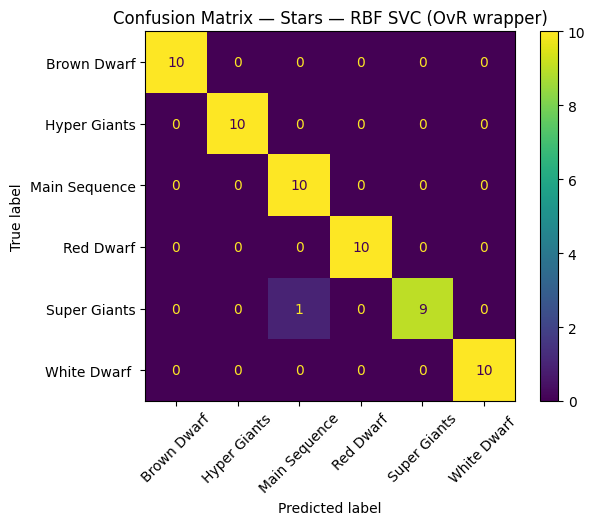

Stars — RBF SVC (OvO wrapper)
  Train time: 0.068 s
  Accuracy:   0.9833
  Macro-F1:   0.9833

               precision    recall  f1-score   support

  Brown Dwarf       1.00      1.00      1.00        10
 Hyper Giants       1.00      1.00      1.00        10
Main Sequence       0.91      1.00      0.95        10
    Red Dwarf       1.00      1.00      1.00        10
 Super Giants       1.00      0.90      0.95        10
 White Dwarf        1.00      1.00      1.00        10

     accuracy                           0.98        60
    macro avg       0.98      0.98      0.98        60
 weighted avg       0.98      0.98      0.98        60



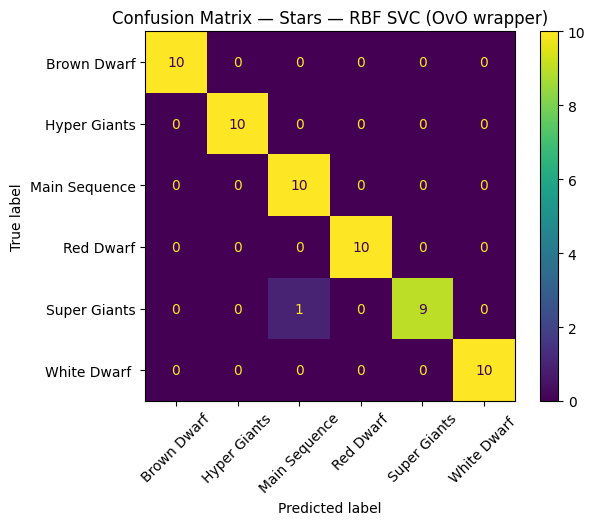

,title,train_time_s,accuracy,macro_f1
0,Stars — RBF SVC (OvR wrapper),0.029873,0.983333,0.983292
1,Stars — RBF SVC (OvO wrapper),0.068265,0.983333,0.983292


In [11]:
target_col = "Type"
Xs = df_stars.drop(columns=[target_col])
ys = df_stars[target_col].astype(str).values

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys, test_size=0.25, random_state=RANDOM_STATE, stratify=ys
)

cat_cols_s = ["Color", "Spectral_Class"]
num_cols_s = [c for c in Xs.columns if c not in cat_cols_s]

prep_stars = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_s),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_s),
    ],
    remainder="drop"
)

base_svc_stars = SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced")

stars_ovr = Pipeline([("prep", prep_stars), ("clf", OneVsRestClassifier(base_svc_stars))])
stars_ovo = Pipeline([("prep", prep_stars), ("clf", OneVsOneClassifier(base_svc_stars))])

res_stars = []
res_stars.append(evaluate_model(stars_ovr, Xs_train, Xs_test, ys_train, ys_test, "Stars — RBF SVC (OvR wrapper)"))
res_stars.append(evaluate_model(stars_ovo, Xs_train, Xs_test, ys_train, ys_test, "Stars — RBF SVC (OvO wrapper)"))
pd.DataFrame(res_stars)



## 12) Direct multi-class SVM: Crammer–Singer formulation (conceptual + practical)

OvR and OvO reduce multi-class to many binary problems.
But there are **direct** multi-class SVM formulations.

One popular formulation is Crammer–Singer.
Let $W = [w_1,\dots,w_K]$ be class-specific weight vectors (linear case).
The prediction rule is:

$$
\hat{y}(x)=\arg\max_{k} w_k^\top x.
$$

The Crammer–Singer objective:

$$
\min_{W,\xi}\;\frac{1}{2}\sum_{k=1}^K \|w_k\|^2 + C\sum_{i=1}^n \xi_i
$$

subject to the constraints for all $i$ and all $k \ne y_i$:

$$
w_{y_i}^\top x_i - w_k^\top x_i \ge 1 - \xi_i,\quad \xi_i\ge 0.
$$

Interpretation:

- You enforce that the correct class score exceeds every incorrect class score by margin 1.
- The slack $\xi_i$ is shared across all constraints for sample $i$.

In scikit-learn, `LinearSVC(multi_class="crammer_singer")` implements a version of this.
It can be slower but sometimes yields better consistency than OvR, especially when classes overlap.

Below we demonstrate how to train it on one dataset and compare against OvR.


Drug200 — LinearSVC multi_class='ovr' (direct)
  Train time: 0.010 s
  Accuracy:   0.9600
  Macro-F1:   0.9553

              precision    recall  f1-score   support

       DrugY       0.96      0.96      0.96        23
       drugA       1.00      1.00      1.00         6
       drugB       1.00      0.75      0.86         4
       drugC       1.00      1.00      1.00         4
       drugX       0.93      1.00      0.96        13

    accuracy                           0.96        50
   macro avg       0.98      0.94      0.96        50
weighted avg       0.96      0.96      0.96        50



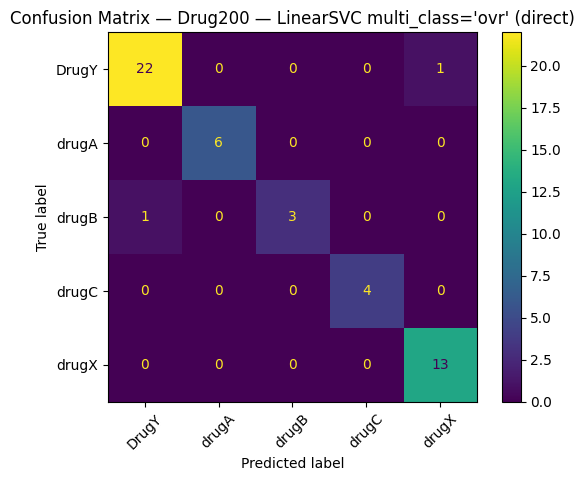

C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Drug200 — LinearSVC multi_class='crammer_singer'
  Train time: 0.112 s
  Accuracy:   0.9600
  Macro-F1:   0.9613

              precision    recall  f1-score   support

       DrugY       1.00      0.91      0.95        23
       drugA       1.00      1.00      1.00         6
       drugB       0.80      1.00      0.89         4
       drugC       1.00      1.00      1.00         4
       drugX       0.93      1.00      0.96        13

    accuracy                           0.96        50
   macro avg       0.95      0.98      0.96        50
weighted avg       0.97      0.96      0.96        50



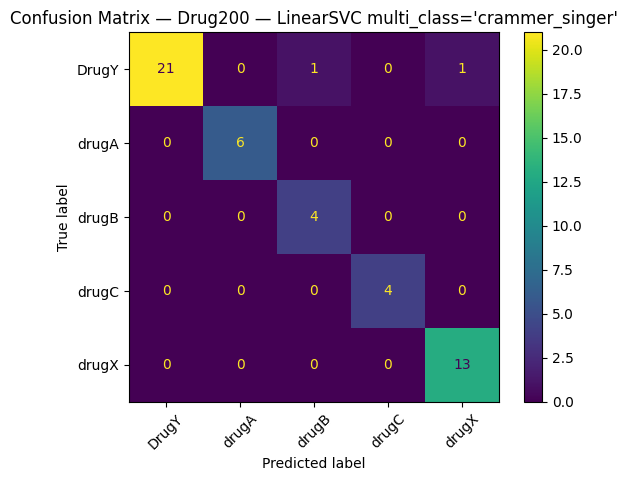

,title,train_time_s,accuracy,macro_f1
0,Drug200 — LinearSVC multi_class='ovr' (direct),0.009679,0.96,0.955326
1,Drug200 — LinearSVC multi_class='crammer_singer',0.112209,0.96,0.961279


In [12]:
# We'll use the Drug200 pipeline (mixed features) and compare OvR vs Crammer-Singer
base_linear_ovr = LinearSVC(C=1.0, class_weight="balanced", multi_class="ovr", random_state=RANDOM_STATE)
base_linear_cs  = LinearSVC(C=1.0, class_weight="balanced", multi_class="crammer_singer", random_state=RANDOM_STATE)

drug_linear_ovr_direct = Pipeline([("prep", prep_drug), ("clf", base_linear_ovr)])
drug_linear_cs = Pipeline([("prep", prep_drug), ("clf", base_linear_cs)])

res_cs = []
res_cs.append(evaluate_model(drug_linear_ovr_direct, Xd_train, Xd_test, yd_train, yd_test, "Drug200 — LinearSVC multi_class='ovr' (direct)"))
res_cs.append(evaluate_model(drug_linear_cs,         Xd_train, Xd_test, yd_train, yd_test, "Drug200 — LinearSVC multi_class='crammer_singer'"))
pd.DataFrame(res_cs)



## 13) Strategy selection checklist (engineering-focused)

When deciding OvR vs OvO (and related choices), use this checklist:

### Data and problem structure

- How many classes ($K$)?  
  - small/moderate $K$ (e.g., 3–20): OvO is feasible
  - large $K$ (e.g., 50–1000): OvR or direct multiclass is usually preferred
- Are classes imbalanced?  
  - use `class_weight="balanced"` or custom weights
  - prefer careful calibration if the decision threshold matters

### Model family

- Linear SVM + sparse features (one-hot, bag-of-words): **OvR is common**
- Kernel SVM:
  - OvO is the default in many libraries (including scikit-learn `SVC`)
  - Can be competitive because each OvO subproblem is smaller

### Compute constraints

- Training budget: OvO may train many models, but each on fewer samples
- Inference budget: OvO may require many pairwise decisions, potentially expensive online

### Output needs

- Need calibrated probabilities?  
  - Consider `CalibratedClassifierCV`
  - Consider OvO + coupling or OvR + careful normalization

### Governance / interpretability

- OvR yields per-class hyperplanes (easier to inspect in linear case)
- OvO yields pairwise separators (can be harder to explain to non-technical stakeholders)

If you’re unsure: start with a **linear OvR baseline** (fast, stable), then move to kernel OvO if you need better nonlinear decision boundaries.



## 14) Exercises (recommended)

1. **Hyperparameter sensitivity**  
   On `glass.csv`, run a small grid over $C \in \{0.5,1,5,10\}$ and $\gamma \in \{\text{"scale"}, 0.1, 1\}$.
   Compare OvR vs OvO for each configuration. Which is more stable?

2. **Class imbalance stress test**  
   On `drug200.csv`, artificially downsample one drug class to create imbalance.  
   Compare:
   - OvR with and without `class_weight="balanced"`
   - Macro-F1 vs accuracy  
   Which metric reflects the issue better?

3. **Probability calibration**  
   Wrap one of your models with `CalibratedClassifierCV`.  
   Compare reliability diagrams (optional) or simply compare log-loss (if you implement it).

4. **Inference benchmarking**  
   Measure prediction time on a large batch for OvR vs OvO.  
   How does it scale with $K$?

5. **Direct multiclass**  
   Compare `LinearSVC(multi_class="ovr")` vs `LinearSVC(multi_class="crammer_singer")` on `stars.csv`.
   Which one is faster? Which one gives better macro-F1?



## References / further reading

- Vapnik, V. N. *The Nature of Statistical Learning Theory*. (Foundations of SVM)
- Cortes, C., & Vapnik, V. (1995). Support-vector networks.
- Crammer, K., & Singer, Y. (2001). On the algorithmic implementation of multiclass kernel-based vector machines.
- Hastie, Tibshirani, Friedman. *The Elements of Statistical Learning* (SVM + multiclass strategies).
- scikit-learn documentation: `SVC`, `LinearSVC`, `OneVsRestClassifier`, `OneVsOneClassifier`, calibration utilities.



## 15) Probability estimates and calibration (when margins are not enough)

SVMs optimize a margin-based loss (hinge loss or a variant). The raw output is a **decision value** (margin),
not a probability. However, many downstream systems (risk scoring, thresholding with costs, human-in-the-loop)
benefit from probabilities.

### 15.1 Multiclass log-loss (a.k.a. cross-entropy)

If a model outputs a probability vector $p(x) \in \Delta^{K-1}$, the multiclass log-loss is:

$$
\mathcal{L}_{\text{log}} = -\frac{1}{n}\sum_{i=1}^n \log p_{y_i}(x_i).
$$

Accuracy can look good while log-loss is bad (overconfident wrong predictions are punished heavily).

### 15.2 Calibration patterns for SVM

Common practical patterns:

**(A) OvO with probability=True (kernel SVC)**  
Some libraries fit a sigmoid per pair (Platt scaling) and then do pairwise coupling to produce a probability vector.

**(B) OvR + per-class calibration**  
Train $K$ binary models, calibrate each to get $p_k(x)$, then normalize:

$$
\tilde{p}_k(x)=\frac{p_k(x)}{\sum_{j=1}^K p_j(x)}.
$$

This gives a simplex vector, though it is not guaranteed to be identical to a direct multinomial model.

**(C) CalibratedClassifierCV**  
In scikit-learn, `CalibratedClassifierCV` wraps a base classifier and learns calibration mapping using CV.
This is often the most reliable for tabular workflows.

Below we calibrate a linear SVM on `drug200.csv` and compare log-loss.


In [13]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss

# Base linear SVM (no probabilities)
lin_base = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)

# Calibrate using 3-fold CV. Method can be 'sigmoid' (Platt) or 'isotonic' (needs more data).
calibrated = CalibratedClassifierCV(lin_base, cv=3, method="sigmoid")

calibrated_pipe = Pipeline([("prep", prep_drug), ("cal", calibrated)])

# Fit on training set
calibrated_pipe.fit(Xd_train, yd_train)

# Predict probabilities
proba = calibrated_pipe.predict_proba(Xd_test)
pred = calibrated_pipe.predict(Xd_test)

print("Calibrated LinearSVC (sigmoid)")
print("  Accuracy:", accuracy_score(yd_test, pred))
print("  Macro-F1:", f1_score(yd_test, pred, average="macro"))
print("  Log-loss:", log_loss(yd_test, proba))


Calibrated LinearSVC (sigmoid)
  Accuracy: 0.92
  Macro-F1: 0.9012820512820513
  Log-loss: 0.3713169133957993



## 16) Inference benchmarking (OvR vs OvO)

Training time is only half of the story. In deployment, you may have strict latency constraints.

A simplified inference-time model:

- OvR: evaluate $K$ decision functions.
- OvO: evaluate $\binom{K}{2}$ decision functions (unless you use DAG-style reduction).

Below we benchmark prediction time on a repeated batch to reduce noise.
(Exact times depend on your CPU and sklearn build; focus on relative scaling.)


In [14]:
def bench_predict(model, X_batch, n_repeat=50, title=""):
    # Warm-up
    model.predict(X_batch)
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        model.predict(X_batch)
    t1 = time.perf_counter()
    per_call_ms = (t1 - t0) * 1000.0 / n_repeat
    print(f"{title} — avg predict time per call: {per_call_ms:.3f} ms (batch size={len(X_batch)})")
    return per_call_ms

# Fit OvR/OvO models on Drug200 (already defined earlier)
drug_ovr.fit(Xd_train, yd_train)
drug_ovo.fit(Xd_train, yd_train)

# Create a batch by repeating the test set
X_batch = pd.concat([Xd_test]*5, ignore_index=True)

t_ovr = bench_predict(drug_ovr, X_batch, n_repeat=100, title="Drug200 LinearSVC OvR")
t_ovo = bench_predict(drug_ovo, X_batch, n_repeat=100, title="Drug200 LinearSVC OvO")


Drug200 LinearSVC OvR — avg predict time per call: 4.520 ms (batch size=250)
Drug200 LinearSVC OvO — avg predict time per call: 6.487 ms (batch size=250)



## 17) Experiment 5 — Fish (multi-class, all numeric)

`fish.csv` has the target `Species` and several numeric length/size features.
Because the features are numeric and relatively low-dimensional, both linear and kernel SVMs are feasible.

Dataset path:

- `"../../../Datasets/Classification/fish.csv"`

We’ll compare:

- Linear SVM (LinearSVC) with OvR
- Kernel SVM (RBF SVC) with OvO wrapper

This also demonstrates that for small $d$, kernel methods can be attractive.


In [15]:
fish_path = "../../../Datasets/Classification/fish.csv"
df_fish = read_csv_safely(fish_path)
df_fish.head()


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


Fish — LinearSVC OvR
  Train time: 0.034 s
  Accuracy:   0.8250
  Macro-F1:   0.7487

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         9
      Parkki       1.00      1.00      1.00         3
       Perch       1.00      0.57      0.73        14
        Pike       1.00      1.00      1.00         4
       Roach       0.45      1.00      0.62         5
       Smelt       0.80      1.00      0.89         4
   Whitefish       0.00      0.00      0.00         1

    accuracy                           0.82        40
   macro avg       0.75      0.80      0.75        40
weighted avg       0.89      0.82      0.82        40



C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

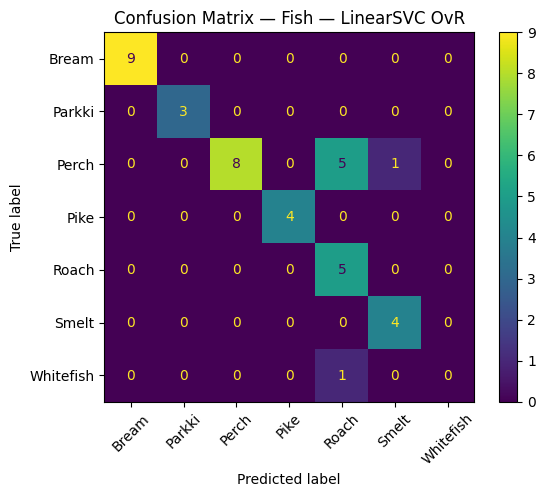

Fish — RBF SVC OvO
  Train time: 0.055 s
  Accuracy:   0.7250
  Macro-F1:   0.8203

              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         9
      Parkki       1.00      1.00      1.00         3
       Perch       1.00      0.21      0.35        14
        Pike       1.00      1.00      1.00         4
       Roach       0.33      1.00      0.50         5
       Smelt       0.80      1.00      0.89         4
   Whitefish       1.00      1.00      1.00         1

    accuracy                           0.72        40
   macro avg       0.88      0.89      0.82        40
weighted avg       0.90      0.72      0.70        40



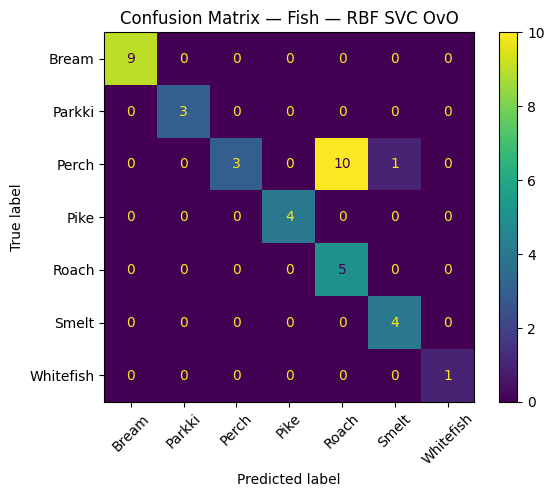

,title,train_time_s,accuracy,macro_f1
0,Fish — LinearSVC OvR,0.034060,0.825,0.748737
1,Fish — RBF SVC OvO,0.055391,0.725,0.820261


In [16]:
target_col = "Species"
Xf = df_fish.drop(columns=[target_col])
yf = df_fish[target_col].astype(str).values

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, yf, test_size=0.25, random_state=RANDOM_STATE, stratify=yf
)

num_cols_f = list(Xf.columns)

prep_fish = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols_f)],
    remainder="drop"
)

fish_linear_ovr = Pipeline([
    ("prep", prep_fish),
    ("clf", OneVsRestClassifier(LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)))
])

fish_kernel_ovo = Pipeline([
    ("prep", prep_fish),
    ("clf", OneVsOneClassifier(SVC(kernel="rbf", C=5.0, gamma="scale", class_weight="balanced")))
])

res_fish = []
res_fish.append(evaluate_model(fish_linear_ovr, Xf_train, Xf_test, yf_train, yf_test, "Fish — LinearSVC OvR"))
res_fish.append(evaluate_model(fish_kernel_ovo, Xf_train, Xf_test, yf_train, yf_test, "Fish — RBF SVC OvO"))
pd.DataFrame(res_fish)



## 18) Beyond OvR/OvO: ECOC and DAG-SVM (high-level)

When $K$ is large, OvO becomes expensive, and OvR may be unstable due to score scaling and imbalance.
Two additional ideas you should know:

### 18.1 ECOC (Error-Correcting Output Codes)

ECOC assigns each class a binary codeword in $\{-1,+1\}^M$ (a code matrix).
You train $M$ binary classifiers, one per code bit, and at inference you pick the class whose codeword is closest
to the predicted bit pattern (e.g., Hamming distance).

Intuition:

- If codewords are far apart, a few bit errors can be corrected.
- You get robustness by redundancy (like error-correcting codes in communication).

### 18.2 DAG-SVM (reducing OvO inference)

OvO voting uses all $\binom{K}{2}$ pairwise models at inference.
DAG-SVM arranges pairwise classifiers in a directed acyclic graph so inference needs only $K-1$ comparisons:
you start with a candidate set of classes and eliminate one class per comparison.

Tradeoff: prediction becomes order-dependent; training remains OvO.

You don’t need these every day, but it’s good to recognize them when reading papers or production systems.
